# Main 2015 Rigorous GPU Notebook (RF + XGBoost + CatBoost)

This notebook mirrors the exp1 preprocessing strategy and is optimized for **accuracy + recall** during hyperparameter search.

Workflow:
1. Data loading and target inference
2. EDA and manual dropping
3. Collinearity heatmap after manual drops
4. KNN imputation + standardization + one-hot encoding
5. Collinearity-driven dropping and post-drop heatmap (colors only)
6. Rigorous GPU-first optimization for Random Forest, XGBoost, CatBoost
7. Calibration with base, Platt, Isotonic, Venn-Abers
8. Final explanation and interpretation

In [33]:
# Optional install (uncomment if needed), then restart kernel once.
%pip install -q numpy pandas scipy scikit-learn joblib xgboost catboost venn-abers seaborn matplotlib imbalanced-learn torch
%pip install -q cuml-cu13 --extra-index-url=https://pypi.nvidia.com

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [34]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [35]:
import json
import random
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.model_selection import ParameterSampler, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)

xgb_available = True
cat_available = True
venn_available = True
torch_available = True
torch_cuda_available = False
cuml_available = True

try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False
    XGBClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    cat_available = False
    CatBoostClassifier = None

try:
    from venn_abers import VennAbers
except Exception:
    venn_available = False
    VennAbers = None

try:
    import torch
    torch_cuda_available = bool(torch.cuda.is_available())
except Exception:
    torch_available = False

try:
    from cuml.ensemble import RandomForestClassifier as cuRFClassifier
except Exception:
    cuml_available = False
    cuRFClassifier = None

print({
    'xgboost': xgb_available,
    'catboost': cat_available,
    'venn_abers': venn_available,
    'torch': torch_available,
    'torch_cuda': torch_cuda_available,
    'cuml_rf': cuml_available,
})

{'xgboost': True, 'catboost': True, 'venn_abers': True, 'torch': True, 'torch_cuda': True, 'cuml_rf': False}


In [36]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'gpu_rf_xgb_cat_exp2_artifacts'
MODEL_DIR = ARTIFACT_DIR / 'models'

for p in [ARTIFACT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET2015_CANDIDATES = [
    PROJECT_ROOT / 'Datasets2015',
    PROJECT_ROOT.parent / 'Datasets2015',
]

AUTO_MERGED_DATA_PATH = None
DATA_CANDIDATES = [
    PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT / 'merged_clinical_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_leftjoin.csv',
]

TARGET_CANDIDATES = ['hypertension', 'htn', 'target', 'label', 'outcome']
COLLINEARITY_CUTOFF = 0.70

STAGE1_EPOCHS = 120
STAGE2_EPOCHS = 300
FINAL_EPOCHS = 900

STAGE1_TRIALS_PER_MODEL = 180
STAGE2_REFINEMENTS_PER_TOP_CONFIG = 24
TOP_K_STAGE1 = 8
TOP_K_STAGE2 = 3
CV_FOLDS_STAGE1 = 5
CV_FOLDS_STAGE2 = 6

USE_GPU_WHEN_AVAILABLE = True
N_JOBS = -1

print('Artifacts:', ARTIFACT_DIR)

Artifacts: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts


In [37]:
def _normalize_join_columns(df_in):
    rename_map = {}
    col_lc = {c.lower(): c for c in df_in.columns}
    for key in ['hhnum', 'member_code']:
        if key in col_lc and col_lc[key] != key:
            rename_map[col_lc[key]] = key
    return df_in.rename(columns=rename_map)

def _find_anthropometric_dataset_path():
    for base in DATASET2015_CANDIDATES:
        anthro_dir = base / 'Anthropometric'
        if not anthro_dir.exists():
            continue

        csv_paths = sorted([p for p in anthro_dir.glob('*.csv') if 'dictionary' not in p.name.lower()])
        preferred = [
            p for p in csv_paths
            if ('data-set' in p.name.lower()) or ('dataset' in p.name.lower())
        ]
        for p in preferred + csv_paths:
            return p
    return None

def _prepare_merged_with_anthro(base_path):
    if not base_path.exists():
        return None

    try:
        base_df = pd.read_csv(base_path)
    except Exception:
        return None

    anthro_tokens = ['weight', 'height', 'waist', 'hip', 'bmi', 'whr']
    has_anthro = any(any(tok in c.lower() for tok in anthro_tokens) for c in base_df.columns)
    if has_anthro:
        return base_path

    anthro_path = _find_anthropometric_dataset_path()
    if anthro_path is None:
        return None

    try:
        anthro_df = pd.read_csv(anthro_path)
    except Exception:
        return None

    base_df = _normalize_join_columns(base_df)
    anthro_df = _normalize_join_columns(anthro_df)

    join_keys = [k for k in ['hhnum', 'member_code'] if k in base_df.columns and k in anthro_df.columns]
    if not join_keys:
        return None

    anthro_df = anthro_df.drop_duplicates(subset=join_keys, keep='first')

    overlap = [c for c in anthro_df.columns if c in base_df.columns and c not in join_keys]
    if overlap:
        anthro_df = anthro_df.rename(columns={c: f'{c}_anthro' for c in overlap})

    merged_df = base_df.merge(anthro_df, on=join_keys, how='left')
    out_path = PROJECT_ROOT / 'merged_clinical_dietary_anthro_leftjoin.csv'
    merged_df.to_csv(out_path, index=False)

    print(f'Prepared anthropometric-augmented dataset: {out_path}')
    print(f'  source merged file: {base_path}')
    print(f'  source anthropometric file: {anthro_path}')
    print(f'  join keys: {join_keys}')
    return out_path

def resolve_data_path(candidates):
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'No dataset found. Checked: {candidates}')

def infer_target_column(df, candidates):
    lc = {c.lower(): c for c in df.columns}
    for t in candidates:
        if t.lower() in lc:
            return lc[t.lower()]
    for c in df.columns:
        c_lc = c.lower()
        if any(t.lower() in c_lc for t in candidates):
            return c
    return None

def infer_bp_columns(df):
    sbp_aliases = ['ave_sbp', 'sbp', 'systolic', 'sysbp', 's_bp']
    dbp_aliases = ['ave_dbp', 'dbp', 'diastolic', 'diabp', 'd_bp']

    lc = {c.lower(): c for c in df.columns}

    sbp_col = None
    for a in sbp_aliases:
        if a in lc:
            sbp_col = lc[a]
            break
    if sbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in sbp_aliases):
                sbp_col = c
                break

    dbp_col = None
    for a in dbp_aliases:
        if a in lc:
            dbp_col = lc[a]
            break
    if dbp_col is None:
        for c in df.columns:
            c_lc = c.lower()
            if any(a in c_lc for a in dbp_aliases):
                dbp_col = c
                break

    return sbp_col, dbp_col

def find_first_column_case_insensitive(columns, candidates):
    lc = {c.lower(): c for c in columns}
    for cand in candidates:
        cand_lc = cand.lower()
        if cand_lc in lc:
            return lc[cand_lc]
    for c in columns:
        c_lc = c.lower()
        if any(cand.lower() in c_lc for cand in candidates):
            return c
    return None

def to_numeric_clean(series):
    s = pd.to_numeric(series, errors='coerce')
    return s.where(~s.isin([9, 99, 888888, 999999]), np.nan)

def build_smoking_level_feature(df_in):
    used_cols = []
    smoking_level_col = find_first_column_case_insensitive(df_in.columns, ['smoking_level'])
    smoke_status_col = find_first_column_case_insensitive(df_in.columns, ['smoke_status'])
    current_smoking_col = find_first_column_case_insensitive(df_in.columns, ['current_smoking', 'currentsmoking'])
    ever_smoke_col = find_first_column_case_insensitive(df_in.columns, ['ever_smk'])

    if smoking_level_col is not None:
        s = to_numeric_clean(df_in[smoking_level_col]).clip(lower=0, upper=3)
        used_cols.append(smoking_level_col)
        return s.astype(float), sorted(set(used_cols))

    idx = df_in.index
    smoke = pd.Series(np.nan, index=idx, dtype=float)

    if smoke_status_col is not None:
        status = to_numeric_clean(df_in[smoke_status_col])
        used_cols.append(smoke_status_col)
        smoke.loc[status == 0] = 0
        smoke.loc[status == 2] = 1
        smoke.loc[status == 1] = 2
        if current_smoking_col is not None:
            current = to_numeric_clean(df_in[current_smoking_col])
            used_cols.append(current_smoking_col)
            smoke.loc[(status == 1) & (current == 3)] = 3
        return smoke.astype(float), sorted(set(used_cols))

    if current_smoking_col is not None:
        current = to_numeric_clean(df_in[current_smoking_col])
        used_cols.append(current_smoking_col)
        smoke.loc[current == 0] = 0
        smoke.loc[current.isin([1, 2])] = 2
        smoke.loc[current == 3] = 3
        if ever_smoke_col is not None:
            ever = to_numeric_clean(df_in[ever_smoke_col])
            used_cols.append(ever_smoke_col)
            smoke.loc[(current == 0) & (ever > 0)] = 1
        return smoke.astype(float), sorted(set(used_cols))

    if ever_smoke_col is not None:
        ever = to_numeric_clean(df_in[ever_smoke_col])
        used_cols.append(ever_smoke_col)
        smoke.loc[ever == 0] = 0
        smoke.loc[ever > 0] = 1
        return smoke.astype(float), sorted(set(used_cols))

    return None, []

def build_alcohol_level_feature(df_in):
    used_cols = []
    alcohol_level_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_level'])
    alcohol_status_col = find_first_column_case_insensitive(df_in.columns, ['alcohol_status'])
    alcohol_ever_col = find_first_column_case_insensitive(df_in.columns, ['alcohol'])
    current_alcohol_col = find_first_column_case_insensitive(df_in.columns, ['con_alcohol'])
    drink30_col = find_first_column_case_insensitive(df_in.columns, ['drnk_30days'])
    binge_col = find_first_column_case_insensitive(df_in.columns, ['binge_drink', 'binge_drinking'])

    if alcohol_level_col is not None:
        a = to_numeric_clean(df_in[alcohol_level_col]).clip(lower=0, upper=3)
        used_cols.append(alcohol_level_col)
        return a.astype(float), sorted(set(used_cols))

    idx = df_in.index
    alcohol = pd.Series(np.nan, index=idx, dtype=float)

    if alcohol_status_col is not None:
        status = to_numeric_clean(df_in[alcohol_status_col])
        used_cols.append(alcohol_status_col)
        alcohol.loc[status == 0] = 0
        alcohol.loc[status == 2] = 1
        alcohol.loc[status == 1] = 2
        if binge_col is not None:
            binge = to_numeric_clean(df_in[binge_col])
            used_cols.append(binge_col)
            alcohol.loc[(status == 1) & (binge == 1)] = 3
        return alcohol.astype(float), sorted(set(used_cols))

    alcohol.loc[:] = 0
    if alcohol_ever_col is not None:
        ever = to_numeric_clean(df_in[alcohol_ever_col])
        used_cols.append(alcohol_ever_col)
        alcohol.loc[ever > 0] = 1
    if current_alcohol_col is not None:
        current = to_numeric_clean(df_in[current_alcohol_col])
        used_cols.append(current_alcohol_col)
        alcohol.loc[current == 1] = np.maximum(alcohol.loc[current == 1], 2)
    if drink30_col is not None:
        d30 = to_numeric_clean(df_in[drink30_col])
        used_cols.append(drink30_col)
        alcohol.loc[d30 == 1] = np.maximum(alcohol.loc[d30 == 1], 2)
    if binge_col is not None:
        binge = to_numeric_clean(df_in[binge_col])
        used_cols.append(binge_col)
        alcohol.loc[binge == 1] = 3

    if used_cols:
        return alcohol.astype(float), sorted(set(used_cols))

    return None, []

def build_bmi_feature(df_in):
    weight_col = find_first_column_case_insensitive(df_in.columns, ['weight'])
    height_col = find_first_column_case_insensitive(df_in.columns, ['height'])
    if weight_col is None or height_col is None:
        return None, []
    w = pd.to_numeric(df_in[weight_col], errors='coerce')
    h = pd.to_numeric(df_in[height_col], errors='coerce')
    h_m = h.copy()
    if pd.notna(h_m.median(skipna=True)) and float(h_m.median(skipna=True)) > 3.0:
        h_m = h_m / 100.0
    bmi = w / (h_m ** 2)
    bmi = bmi.replace([np.inf, -np.inf], np.nan)
    return bmi.astype(float), [weight_col, height_col]

def build_whr_feature(df_in):
    waist_col = find_first_column_case_insensitive(df_in.columns, ['waist'])
    hip_col = find_first_column_case_insensitive(df_in.columns, ['hip'])
    if waist_col is None or hip_col is None:
        return None, []
    waist = pd.to_numeric(df_in[waist_col], errors='coerce')
    hip = pd.to_numeric(df_in[hip_col], errors='coerce').replace(0, np.nan)
    whr = (waist / hip).replace([np.inf, -np.inf], np.nan)
    return whr.astype(float), [waist_col, hip_col]

In [38]:
AUTO_MERGED_DATA_PATH = None
for merged_candidate in [
    PROJECT_ROOT / 'merged_clinical_dietary_leftjoin.csv',
    PROJECT_ROOT.parent / 'merged_clinical_dietary_leftjoin.csv',
]:
    AUTO_MERGED_DATA_PATH = _prepare_merged_with_anthro(merged_candidate)
    if AUTO_MERGED_DATA_PATH is not None:
        break

effective_candidates = [
    AUTO_MERGED_DATA_PATH,
    *DATA_CANDIDATES,
]
effective_candidates = [p for p in effective_candidates if p is not None]

data_path = resolve_data_path(effective_candidates)
df = pd.read_csv(data_path)
target_col = infer_target_column(df, TARGET_CANDIDATES)
TARGET_DEFINED_FROM_BP = False
TARGET_SOURCE_COLUMNS = []

if target_col is None:
    sbp_col, dbp_col = infer_bp_columns(df)
    if sbp_col is not None and dbp_col is not None:
        sbp = pd.to_numeric(df[sbp_col], errors='coerce')
        dbp = pd.to_numeric(df[dbp_col], errors='coerce')
        df['Hypertension'] = (((sbp >= 130) | (dbp >= 80)).fillna(False)).astype(int)
        target_col = 'Hypertension'
        TARGET_DEFINED_FROM_BP = True
        TARGET_SOURCE_COLUMNS = [sbp_col, dbp_col]
        print(f'Target column created from: {sbp_col}, {dbp_col}')
    else:
        raise ValueError('Could not infer target and could not derive Hypertension from SBP/DBP (130/80 OR rule).')

df = df.dropna(subset=[target_col]).copy()
y_raw = df[target_col]
if y_raw.nunique() != 2:
    raise ValueError(f'Target must be binary. Found {y_raw.nunique()} classes.')

if y_raw.dtype == 'O':
    y = pd.Series(LabelEncoder().fit_transform(y_raw.astype(str)), index=y_raw.index, name=target_col)
else:
    y = pd.Series(y_raw.astype(int), index=y_raw.index, name=target_col)

X = df.drop(columns=[target_col]).copy()

smoking_feature, smoking_sources = build_smoking_level_feature(X)
if smoking_feature is not None:
    X['fe_smoking_level'] = smoking_feature

alcohol_feature, alcohol_sources = build_alcohol_level_feature(X)
if alcohol_feature is not None:
    X['fe_alcohol_level'] = alcohol_feature

bmi_feature, bmi_sources = build_bmi_feature(X)
if bmi_feature is not None:
    X['bmi'] = bmi_feature

whr_feature, whr_sources = build_whr_feature(X)
if whr_feature is not None:
    X['whr'] = whr_feature

behavior_raw_candidates = [
    'current_smoking', 'currentsmoking', 'ever_smk', 'smoke_status', 'smoking_level',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drink', 'binge_drinking', 'alcohol_level',
]
x_lc = {c.lower(): c for c in X.columns}
behavior_drop = sorted({x_lc[c.lower()] for c in behavior_raw_candidates if c.lower() in x_lc})
if behavior_drop:
    X = X.drop(columns=behavior_drop, errors='ignore')

anthro_source_drop = sorted({
    c for c in set((bmi_sources or []) + (whr_sources or []))
    if c in X.columns and c.lower() not in {'bmi', 'whr'}
})
if anthro_source_drop:
    X = X.drop(columns=anthro_source_drop, errors='ignore')

NON_REMOVABLE_BASE_ALIASES = ['age', 'sex']

manual_non_predictive = [
    'regcode', 'provcode', 'provhuc', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'fwgt', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'ms_psucode', 'enns_year', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'hhnum', 'member_code',
    'ave_sbp', 'ave_dbp', 'sbp', 'dbp', 'systolic', 'diastolic', 'sysbp', 'diabp',
    'blood_pressure',
    'height', 'weight', 'waist', 'hip',
]
x_lc = {c.lower(): c for c in X.columns}
manual_drop = sorted({x_lc[c.lower()] for c in manual_non_predictive if c.lower() in x_lc})

protected_base_cols = []
for col in X.columns:
    col_lc = col.lower()
    if any(alias in col_lc for alias in NON_REMOVABLE_BASE_ALIASES):
        protected_base_cols.append(col)
protected_base_cols = sorted(set(protected_base_cols))

if manual_drop:
    protected_drop = [c for c in manual_drop if c in protected_base_cols]
    if protected_drop:
        print('Manual-drop protection triggered for non-removable base features:', protected_drop)
    manual_drop = [c for c in manual_drop if c not in protected_base_cols]
    X = X.drop(columns=manual_drop, errors='ignore')

base_removed_non_removable = []
for alias in NON_REMOVABLE_BASE_ALIASES:
    if not any(alias in c.lower() for c in X.columns):
        base_removed_non_removable.append(alias)

RETRAIN_REQUIRED_NON_REMOVABLE = len(base_removed_non_removable) > 0

print(f'Loaded: {data_path}')
print(f'Auto merged dataset: {AUTO_MERGED_DATA_PATH}')
print(f'Target: {target_col}')
print(f'Target defined from BP fallback: {TARGET_DEFINED_FROM_BP}')
print(f'Raw rows: {len(df)}')
print(f'Features after manual preprocessing: {X.shape[1]}')
print(f'Manual dropped columns: {len(manual_drop)}')
print(f'Behavior raw dropped columns: {len(behavior_drop)}')
print(f'Anthropometric source dropped columns: {len(anthro_source_drop)}')
print('Protected non-removable base columns:', protected_base_cols)
print('Missing non-removable base aliases after base preprocessing:', base_removed_non_removable)
print('Class balance:', y.value_counts(normalize=True).to_dict())

Prepared anthropometric-augmented dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
  source merged file: /workspace/Thesis-part-2/merged_clinical_dietary_leftjoin.csv
  source anthropometric file: /workspace/Thesis-part-2/Datasets2015/Anthropometric/Jonathan Ralph_Baes_2026-03-26141834_data-set_anthrop.csv
  join keys: ['hhnum', 'member_code']
Target column created from: Ave_SBP, Ave_DBP
Loaded: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Auto merged dataset: /workspace/Thesis-part-2/merged_clinical_dietary_anthro_leftjoin.csv
Target: Hypertension
Target defined from BP fallback: True
Raw rows: 151189
Features after manual preprocessing: 57
Manual dropped columns: 14
Behavior raw dropped columns: 9
Anthropometric source dropped columns: 4
Protected non-removable base columns: ['age', 'age_anthro', 'agemos', 'sex', 'sex_anthro']
Missing non-removable base aliases after base preprocessing: []
Class balance: {0: 0.6638379776306478, 1: 

EDA directory: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda
Image output directory: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/images
Table output directory: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/tables
Sample size: 151,189
Target distribution (count):
Hypertension
0    100365
1     50824
Target distribution (proportion):
Hypertension
0    0.6638
1    0.3362
Numeric features for target-association analysis: 57
Saved target relationship table: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/tables/target_relationship_numeric_features.csv
Top 20 numeric features by |Spearman correlation| with target:
         feature  spearman_corr_target  abs_spearman_corr_target  std_mean_diff_target1_vs_0
             age              0.520871                  0.520871                    1.259851
          agemos              0.520871                  0.520871                    1.259851
      age_anthro              0.520871               

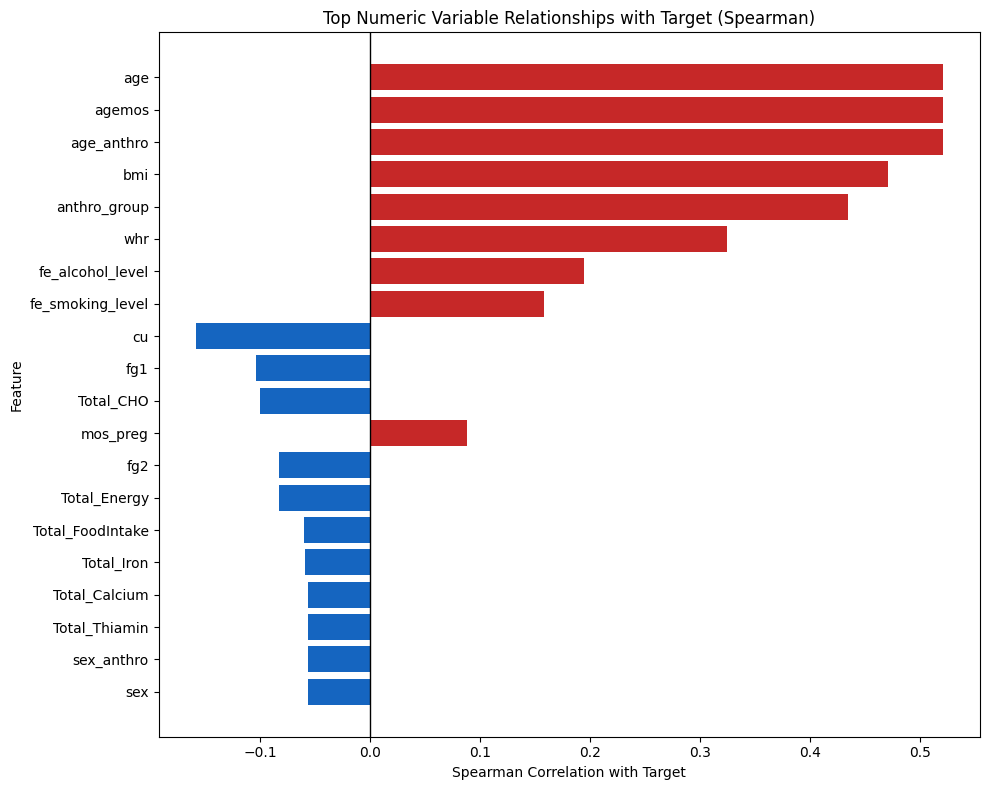

Saved target-relationship figure: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/images/target_relationship_top20_spearman.png


In [39]:
# Rigorous EDA block (paper-ready): target relationships + artifact folders
EDA_DIR = ARTIFACT_DIR / 'eda'
EDA_IMG_DIR = EDA_DIR / 'images'
EDA_TABLE_DIR = EDA_DIR / 'tables'
for p in [EDA_DIR, EDA_IMG_DIR, EDA_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'EDA directory: {EDA_DIR}')
print(f'Image output directory: {EDA_IMG_DIR}')
print(f'Table output directory: {EDA_TABLE_DIR}')
print(f'Sample size: {len(X):,}')
print('Target distribution (count):')
print(y.value_counts(dropna=False).to_string())
print('Target distribution (proportion):')
print(y.value_counts(normalize=True, dropna=False).round(4).to_string())

num_cols_eda = X.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric features for target-association analysis: {len(num_cols_eda)}')

def _safe_smd(x0: pd.Series, x1: pd.Series) -> float:
    x0 = pd.to_numeric(x0, errors='coerce').dropna()
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    m0, m1 = x0.mean(), x1.mean()
    v0, v1 = x0.var(ddof=1), x1.var(ddof=1)
    pooled = np.sqrt((v0 + v1) / 2.0)
    if pooled == 0 or np.isnan(pooled):
        return np.nan
    return float((m1 - m0) / pooled)

target_numeric = pd.to_numeric(y, errors='coerce')
rows = []
for c in num_cols_eda:
    s = pd.to_numeric(X[c], errors='coerce')
    valid = s.notna() & target_numeric.notna()
    n_valid = int(valid.sum())
    if n_valid < 5:
        continue

    corr_spearman = s[valid].corr(target_numeric[valid], method='spearman')
    grp0 = s[valid & (target_numeric == 0)]
    grp1 = s[valid & (target_numeric == 1)]

    rows.append(
        {
            'feature': c,
            'n_valid': n_valid,
            'spearman_corr_target': float(corr_spearman) if pd.notna(corr_spearman) else np.nan,
            'abs_spearman_corr_target': abs(float(corr_spearman)) if pd.notna(corr_spearman) else np.nan,
            'mean_target0': float(grp0.mean()) if len(grp0) else np.nan,
            'mean_target1': float(grp1.mean()) if len(grp1) else np.nan,
            'std_mean_diff_target1_vs_0': _safe_smd(grp0, grp1),
        }
    )

target_relation_df = pd.DataFrame(rows).sort_values('abs_spearman_corr_target', ascending=False).reset_index(drop=True)
target_relation_path = EDA_TABLE_DIR / 'target_relationship_numeric_features.csv'
target_relation_df.to_csv(target_relation_path, index=False)

print(f'Saved target relationship table: {target_relation_path}')
print('Top 20 numeric features by |Spearman correlation| with target:')
print(target_relation_df[['feature', 'spearman_corr_target', 'abs_spearman_corr_target', 'std_mean_diff_target1_vs_0']].head(20).to_string(index=False))

if not target_relation_df.empty:
    plot_df = target_relation_df.head(20).iloc[::-1].copy()
    plt.figure(figsize=(10, 8))
    colors = ['#c62828' if v >= 0 else '#1565c0' for v in plot_df['spearman_corr_target']]
    plt.barh(plot_df['feature'], plot_df['spearman_corr_target'], color=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Top Numeric Variable Relationships with Target (Spearman)')
    plt.xlabel('Spearman Correlation with Target')
    plt.ylabel('Feature')
    plt.tight_layout()
    target_rel_fig_path = EDA_IMG_DIR / 'target_relationship_top20_spearman.png'
    plt.savefig(target_rel_fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved target-relationship figure: {target_rel_fig_path}')

Numeric columns for supplementary manual-drop heatmap: 57


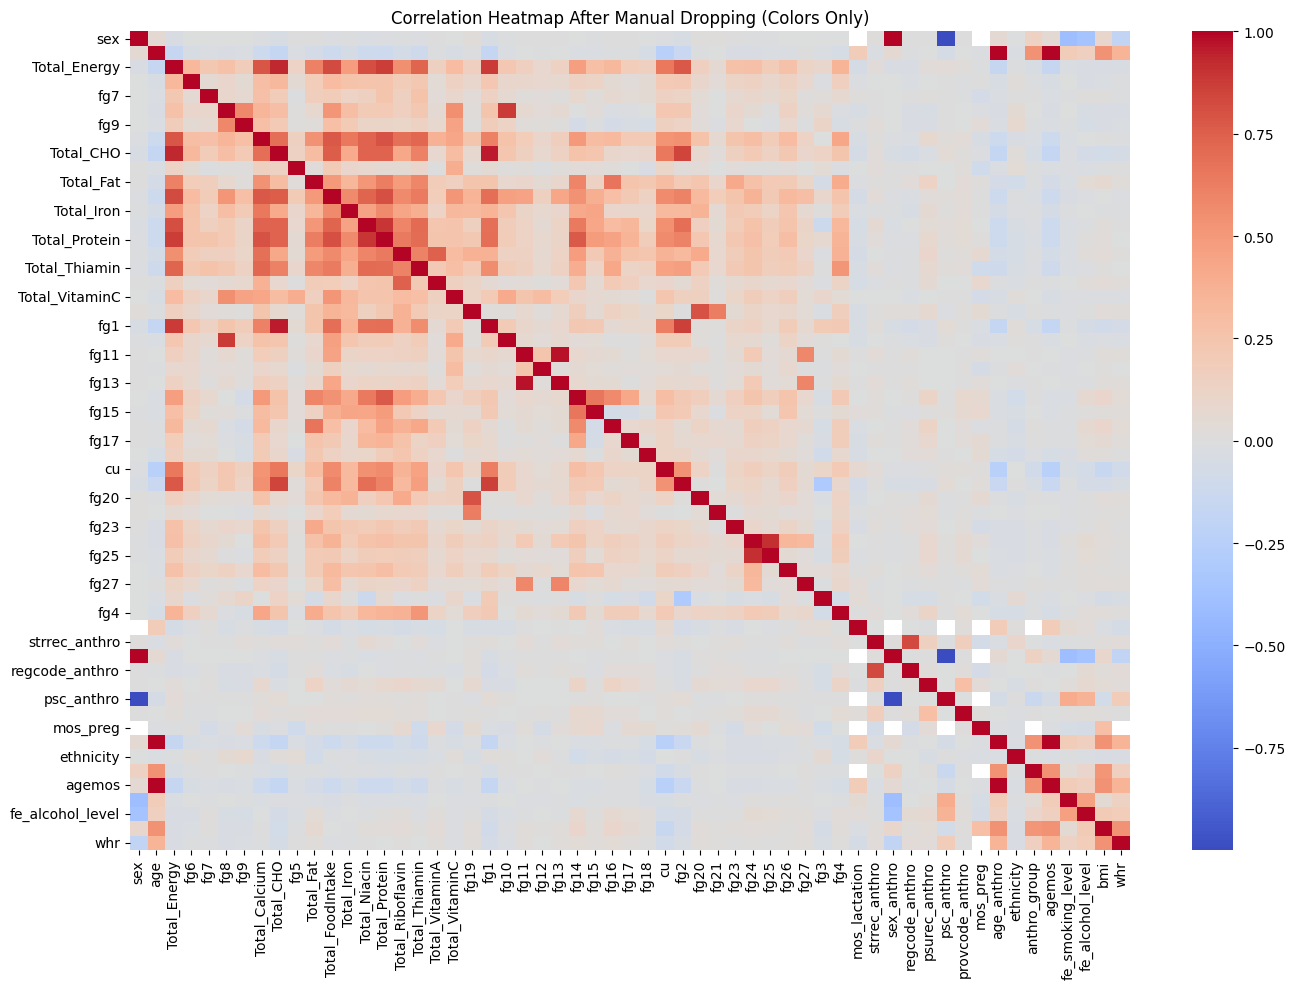

Saved supplementary manual-drop heatmap: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/images/heatmap_after_manual_dropping.png


In [40]:
# Supplementary EDA heatmap after manual dropping (colors only, no correlation values).
if 'EDA_DIR' not in globals():
    EDA_DIR = ARTIFACT_DIR / 'eda'
    EDA_IMG_DIR = EDA_DIR / 'images'
    EDA_TABLE_DIR = EDA_DIR / 'tables'
for p in [EDA_DIR, EDA_IMG_DIR, EDA_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

num_cols_manual = X.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns for supplementary manual-drop heatmap:', len(num_cols_manual))

if len(num_cols_manual) > 1:
    corr_manual = X[num_cols_manual].corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_manual, cmap='coolwarm', center=0, annot=False, cbar=True)
    plt.title('Correlation Heatmap After Manual Dropping (Colors Only)')
    plt.tight_layout()
    manual_heatmap_path = EDA_IMG_DIR / 'heatmap_after_manual_dropping.png'
    plt.savefig(manual_heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved supplementary manual-drop heatmap: {manual_heatmap_path}')
else:
    print('Not enough numeric columns to plot manual-drop heatmap.')

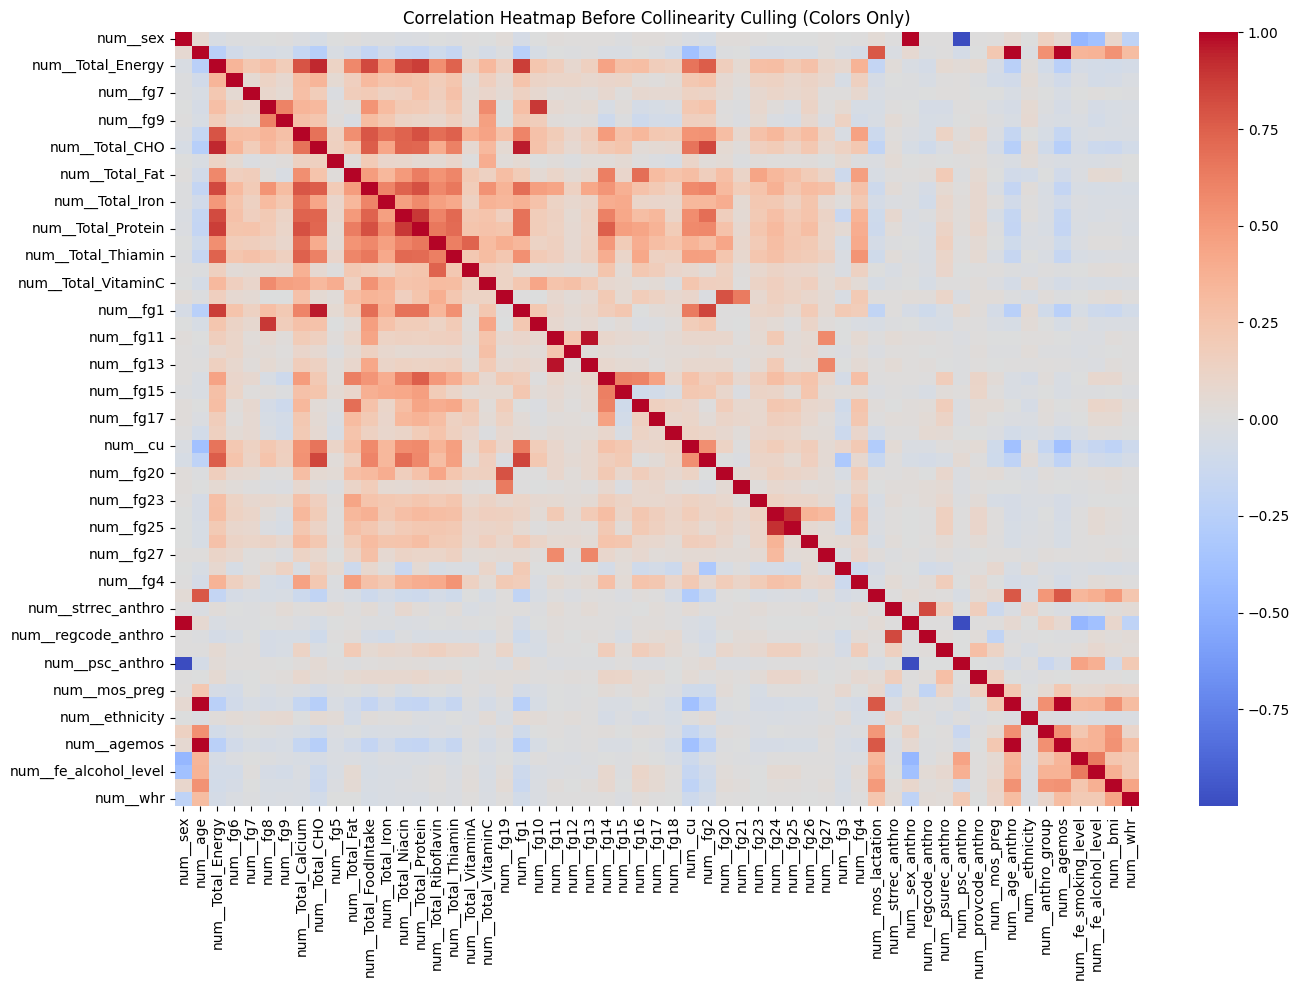

Saved pre-culling heatmap: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/images/heatmap_before_collinearity_culling.png
Saved pre-culling high-collinearity table: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/tables/collinearity_pairs_before_culling_gt_0.70.csv
Pre-culling |corr| > 0.70 pair count: 39
            feature_1             feature_2      corr  abs_corr
             num__age       num__age_anthro  1.000000  1.000000
             num__sex       num__sex_anthro  1.000000  1.000000
      num__age_anthro           num__agemos  1.000000  1.000000
             num__age           num__agemos  1.000000  1.000000
      num__sex_anthro       num__psc_anthro -0.999978  0.999978
             num__sex       num__psc_anthro -0.999978  0.999978
            num__fg11             num__fg13  0.976530  0.976530
       num__Total_CHO              num__fg1  0.958539  0.958539
    num__Total_Energy        num__Total_CHO  0.931549  0.931549
            num__fg24          

In [41]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_tmp
)

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_ohe()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ],
    remainder='drop',
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_valid_proc = pd.DataFrame(X_valid_proc, columns=feature_names, index=X_valid.index)
X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

# Ensure EDA folders exist even if the standalone EDA cell was skipped.
if 'EDA_DIR' not in globals():
    EDA_DIR = ARTIFACT_DIR / 'eda'
    EDA_IMG_DIR = EDA_DIR / 'images'
    EDA_TABLE_DIR = EDA_DIR / 'tables'
for p in [EDA_DIR, EDA_IMG_DIR, EDA_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def high_collinearity_pairs(corr_df: pd.DataFrame, cutoff: float = 0.70) -> pd.DataFrame:
    abs_corr = corr_df.abs()
    upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
    pairs = []
    for c in upper.columns:
        rows = upper.index[upper[c] > cutoff].tolist()
        for r in rows:
            pairs.append(
                {
                    'feature_1': r,
                    'feature_2': c,
                    'corr': float(corr_df.loc[r, c]),
                    'abs_corr': float(abs_corr.loc[r, c]),
                }
            )
    if not pairs:
        return pd.DataFrame(columns=['feature_1', 'feature_2', 'corr', 'abs_corr'])
    return pd.DataFrame(pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)

# Heatmap BEFORE collinearity culling (colors only).
corr_pre_cull = X_train_proc.corr(numeric_only=True)
if corr_pre_cull.shape[1] > 1:
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_pre_cull, cmap='coolwarm', center=0, annot=False, cbar=True)
    plt.title('Correlation Heatmap Before Collinearity Culling (Colors Only)')
    plt.tight_layout()
    pre_heatmap_path = EDA_IMG_DIR / 'heatmap_before_collinearity_culling.png'
    plt.savefig(pre_heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved pre-culling heatmap: {pre_heatmap_path}')
else:
    print('Not enough processed features to plot pre-culling heatmap.')

high_corr_pre_df = high_collinearity_pairs(corr_pre_cull, cutoff=COLLINEARITY_CUTOFF)
high_corr_pre_path = EDA_TABLE_DIR / f'collinearity_pairs_before_culling_gt_{COLLINEARITY_CUTOFF:.2f}.csv'
high_corr_pre_df.to_csv(high_corr_pre_path, index=False)
print(f'Saved pre-culling high-collinearity table: {high_corr_pre_path}')
print(f'Pre-culling |corr| > {COLLINEARITY_CUTOFF:.2f} pair count: {len(high_corr_pre_df)}')
if not high_corr_pre_df.empty:
    print(high_corr_pre_df.head(30).to_string(index=False))

# Protect only canonical age/sex features (not every alias like age_anthro/agemos/sex_anthro).
NON_REMOVABLE_PROCESSED_ALIASES = ['age', 'sex']
canonical_non_removable_processed_cols = [
    c for c in ['num__age', 'num__sex'] if c in X_train_proc.columns
]

# Fallback only if canonical names are absent.
if not canonical_non_removable_processed_cols:
    non_removable_processed_cols = []
    for c in X_train_proc.columns:
        c_lc = c.lower()
        if any(alias in c_lc for alias in NON_REMOVABLE_PROCESSED_ALIASES):
            non_removable_processed_cols.append(c)
    non_removable_processed_cols = sorted(set(non_removable_processed_cols))
else:
    non_removable_processed_cols = sorted(set(canonical_non_removable_processed_cols))

protected_cols = sorted(set([c for c in ['num__bmi', 'num__whr'] if c in X_train_proc.columns] + non_removable_processed_cols))

def collinearity_filter(df_in, cutoff=0.70, protected=None):
    protected_set = set(protected or [])
    corr = df_in.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = []
    for c in upper.columns:
        if c in protected_set:
            continue
        if (upper[c] > cutoff).any():
            drop_cols.append(c)
    keep_cols = [c for c in df_in.columns if c not in drop_cols]
    return keep_cols, drop_cols

keep_cols, dropped_cols = collinearity_filter(
    X_train_proc, cutoff=COLLINEARITY_CUTOFF, protected=protected_cols
)

missing_non_removable_after_filter = [c for c in non_removable_processed_cols if c not in keep_cols]
if missing_non_removable_after_filter:
    keep_cols = keep_cols + missing_non_removable_after_filter
    dropped_cols = [c for c in dropped_cols if c not in set(missing_non_removable_after_filter)]
    RETRAIN_REQUIRED_NON_REMOVABLE = True

X_train_final = X_train_proc[keep_cols].copy()
X_valid_final = X_valid_proc[keep_cols].copy()
X_test_final = X_test_proc[keep_cols].copy()

missing_non_removable_final = []
for c in non_removable_processed_cols:
    if c not in X_train_final.columns:
        missing_non_removable_final.append(c)

if missing_non_removable_final:
    RETRAIN_REQUIRED_NON_REMOVABLE = True
    raise ValueError(
        f'Non-removable processed features missing from final matrix: {missing_non_removable_final}. '
        'Please verify source columns for age/sex are present before training.'
    )

print('Train/Valid/Test shapes:', X_train_final.shape, X_valid_final.shape, X_test_final.shape)
print('Protected cols:', protected_cols)
print('Non-removable processed cols:', non_removable_processed_cols)
print('Missing non-removable after collinearity filter (recovered):', missing_non_removable_after_filter)
print(f'Collinearity dropped: {len(dropped_cols)}')
print('Retrain required due to non-removable check:', RETRAIN_REQUIRED_NON_REMOVABLE)

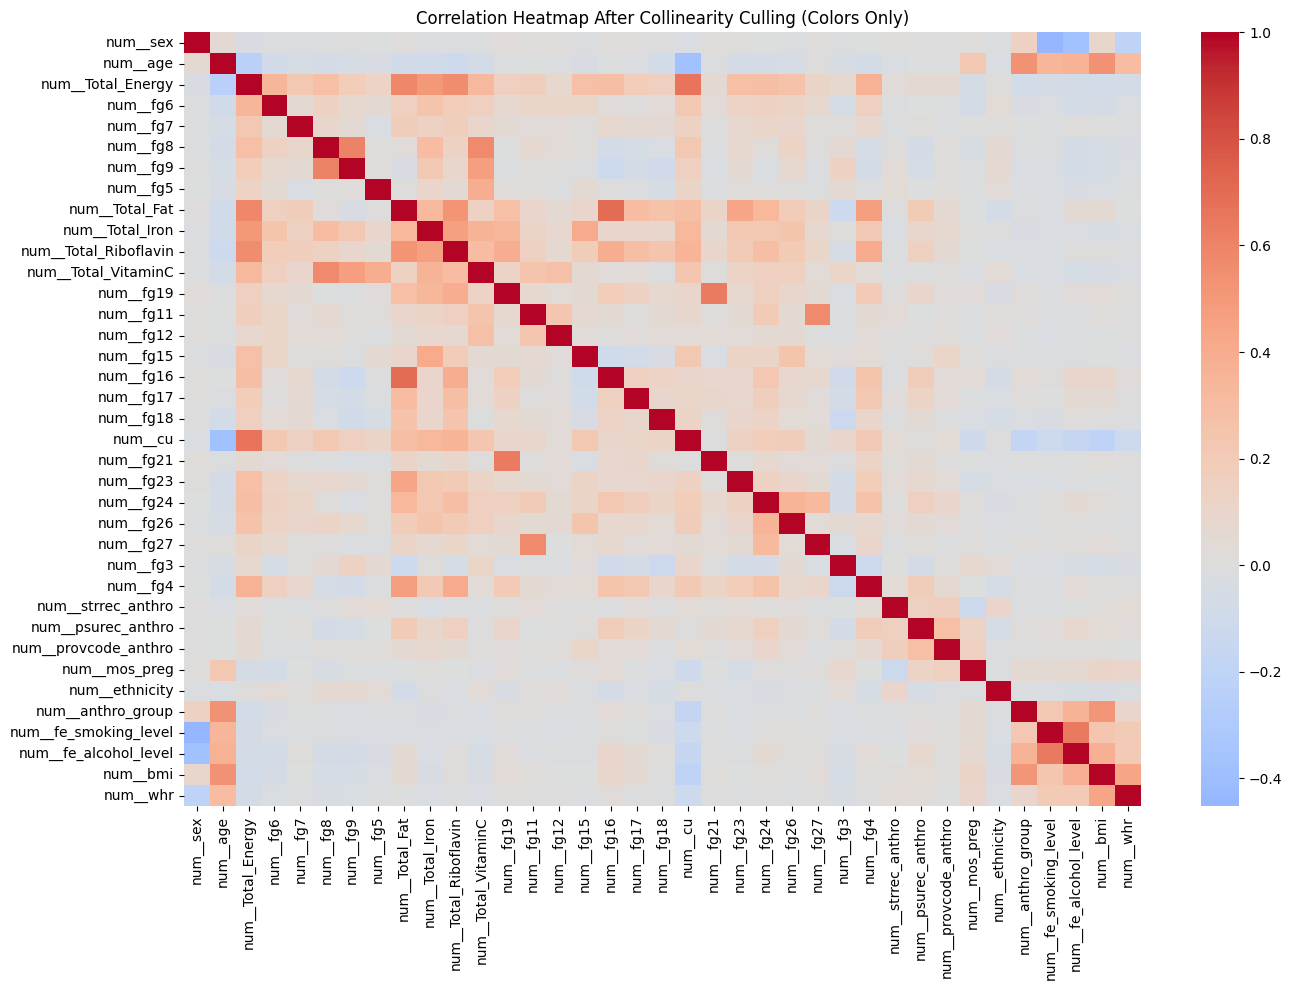

Saved post-culling heatmap: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/images/heatmap_after_collinearity_culling.png
Saved post-culling high-collinearity table: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/eda/tables/collinearity_pairs_after_culling_gt_0.70.csv
Post-culling |corr| > 0.70 pair count: 0


In [ ]:
# Heatmap AFTER collinearity-based culling (colors only) + confirmation table for paper.
if 'EDA_DIR' not in globals():
    EDA_DIR = ARTIFACT_DIR / 'eda'
    EDA_IMG_DIR = EDA_DIR / 'images'
    EDA_TABLE_DIR = EDA_DIR / 'tables'
for p in [EDA_DIR, EDA_IMG_DIR, EDA_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

if 'high_collinearity_pairs' not in globals():
    def high_collinearity_pairs(corr_df: pd.DataFrame, cutoff: float = 0.70) -> pd.DataFrame:
        abs_corr = corr_df.abs()
        upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
        pairs = []
        for c in upper.columns:
            rows = upper.index[upper[c] > cutoff].tolist()
            for r in rows:
                pairs.append(
                    {
                        'feature_1': r,
                        'feature_2': c,
                        'corr': float(corr_df.loc[r, c]),
                        'abs_corr': float(abs_corr.loc[r, c]),
                    }
                )
        if not pairs:
            return pd.DataFrame(columns=['feature_1', 'feature_2', 'corr', 'abs_corr'])
        return pd.DataFrame(pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)

if X_train_final.shape[1] > 1:
    corr_final = X_train_final.corr(numeric_only=True)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_final, cmap='coolwarm', center=0, annot=False, cbar=True)
    plt.title('Correlation Heatmap After Collinearity Culling (Colors Only)')
    plt.tight_layout()
    post_heatmap_path = EDA_IMG_DIR / 'heatmap_after_collinearity_culling.png'
    plt.savefig(post_heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved post-culling heatmap: {post_heatmap_path}')

    high_corr_post_df = high_collinearity_pairs(corr_final, cutoff=COLLINEARITY_CUTOFF)
    high_corr_post_path = EDA_TABLE_DIR / f'collinearity_pairs_after_culling_gt_{COLLINEARITY_CUTOFF:.2f}.csv'
    high_corr_post_df.to_csv(high_corr_post_path, index=False)
    print(f'Saved post-culling high-collinearity table: {high_corr_post_path}')
    print(f'Post-culling |corr| > {COLLINEARITY_CUTOFF:.2f} pair count: {len(high_corr_post_df)}')
    if not high_corr_post_df.empty:
        print(high_corr_post_df.head(30).to_string(index=False))
else:
    print('Not enough final features to plot post-collinearity heatmap.')

In [ ]:
# Save fitted preprocessor to disk
import joblib
preprocessor_save_path = ARTIFACT_DIR / 'preprocessor.joblib'
joblib.dump(preprocessor, preprocessor_save_path)
print(f'Saved preprocessor to: {preprocessor_save_path}')
print(f'Preprocessor type: {type(preprocessor)}')
if hasattr(preprocessor, 'feature_names_in_'):
    print(f'Input features ({len(preprocessor.feature_names_in_)}): {list(preprocessor.feature_names_in_)}')
out_names = preprocessor.get_feature_names_out()
print(f'Output features ({len(out_names)}): {list(out_names)}')

Saved preprocessor to: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/preprocessor.joblib
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Input features (57): ['sex', 'age', 'Total_Energy', 'fg6', 'fg7', 'fg8', 'fg9', 'Total_Calcium', 'Total_CHO', 'fg5', 'Total_Fat', 'Total_FoodIntake', 'Total_Iron', 'Total_Niacin', 'Total_Protein', 'Total_Riboflavin', 'Total_Thiamin', 'Total_VitaminA', 'Total_VitaminC', 'fg19', 'fg1', 'fg10', 'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'cu', 'fg2', 'fg20', 'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'fg3', 'fg4', 'mos_lactation', 'strrec_anthro', 'sex_anthro', 'regcode_anthro', 'psurec_anthro', 'psc_anthro', 'provcode_anthro', 'mos_preg', 'age_anthro', 'ethnicity', 'anthro_group', 'agemos', 'fe_smoking_level', 'fe_alcohol_level', 'bmi', 'whr']
Output features (57): ['num__sex', 'num__age', 'num__Total_Energy', 'num__fg6', 'num__fg7', 'num__fg8', 'num__fg9', 'num__Total_Calcium', 'num__

In [ ]:
MODEL_SPACES = {
    'random_forest': {
        'max_depth': [None, 6, 8, 12, 16, 22],
        'min_samples_split': randint(2, 24),
        'min_samples_leaf': randint(1, 12),
        'max_features': ['sqrt', 'log2', 0.4, 0.6, 0.8],
    },
    'xgboost': {
        'learning_rate': uniform(0.01, 0.24),
        'max_depth': randint(3, 11),
        'subsample': uniform(0.60, 0.40),
        'colsample_bytree': uniform(0.60, 0.40),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0.0, 2.0),
        'reg_lambda': loguniform(1e-3, 30),
    },
    'catboost': {
        'learning_rate': uniform(0.01, 0.24),
        'depth': randint(4, 11),
        'l2_leaf_reg': loguniform(1.0, 30.0),
        'random_strength': uniform(0.0, 2.0),
    },
}

AVAILABLE_MODELS = ['random_forest']
if xgb_available:
    AVAILABLE_MODELS.append('xgboost')
if cat_available:
    AVAILABLE_MODELS.append('catboost')

print('Models:', AVAILABLE_MODELS)

Models: ['random_forest', 'xgboost', 'catboost']


In [ ]:
def safe_predict_proba(model, X):
    p = model.predict_proba(X)
    if hasattr(p, 'get'):
        p = p.get()
    p = np.asarray(p)
    if p.ndim == 2:
        return np.clip(p[:, 1], 1e-6, 1 - 1e-6)
    return np.clip(p.reshape(-1), 1e-6, 1 - 1e-6)

def metric_pack(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob), 1e-6, 1 - 1e-6)
    y_pred = (y_prob >= threshold).astype(int)
    auc_val = 0.5 if np.unique(y_true).size < 2 else roc_auc_score(y_true, y_prob)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': auc_val,
        'logloss': log_loss(y_true, y_prob, labels=[0, 1]),
    }

def optimization_score(metrics):
    # Primary objective requested: maximize accuracy and recall.
    # Secondary terms stabilize selection and avoid degenerate thresholds.
    return (
        0.60 * float(metrics['accuracy_mean'])
        + 0.40 * float(metrics['recall_mean'])
        + 0.05 * float(metrics['f1_mean'])
        - 0.08 * float(metrics['logloss_mean'])
        - 0.03 * float(metrics['accuracy_std'])
        - 0.03 * float(metrics['recall_std'])
    )

def build_model(model_name, params, epoch_budget):
    p = deepcopy(params)
    use_gpu = bool(USE_GPU_WHEN_AVAILABLE and torch_cuda_available)

    if model_name == 'random_forest':
        if use_gpu and cuml_available:
            return cuRFClassifier(
                n_estimators=int(epoch_budget),
                max_depth=16 if p['max_depth'] is None else int(p['max_depth']),
                max_features=1.0 if isinstance(p['max_features'], str) else float(p['max_features']),
                random_state=RANDOM_SEED,
            )
        return RandomForestClassifier(
            n_estimators=int(epoch_budget),
            max_depth=p['max_depth'],
            min_samples_split=int(p['min_samples_split']),
            min_samples_leaf=int(p['min_samples_leaf']),
            max_features=p['max_features'],
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
            class_weight='balanced_subsample',
        )

    if model_name == 'xgboost':
        return XGBClassifier(
            n_estimators=int(epoch_budget),
            learning_rate=float(p['learning_rate']),
            max_depth=int(p['max_depth']),
            subsample=float(p['subsample']),
            colsample_bytree=float(p['colsample_bytree']),
            min_child_weight=float(p['min_child_weight']),
            gamma=float(p['gamma']),
            reg_lambda=float(p['reg_lambda']),
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_SEED,
            n_jobs=N_JOBS,
            tree_method='hist',
            device='cuda' if use_gpu else 'cpu',
            verbosity=0,
        )

    if model_name == 'catboost':
        kwargs = {
            'iterations': int(epoch_budget),
            'learning_rate': float(p['learning_rate']),
            'depth': int(p['depth']),
            'l2_leaf_reg': float(p['l2_leaf_reg']),
            'random_strength': float(p['random_strength']),
            'loss_function': 'Logloss',
            'eval_metric': 'Logloss',
            'random_seed': RANDOM_SEED,
            'thread_count': N_JOBS,
            'verbose': False,
        }
        if use_gpu:
            kwargs['task_type'] = 'GPU'
            kwargs['devices'] = '0'
        return CatBoostClassifier(**kwargs)

    raise ValueError(f'Unsupported model: {model_name}')

def fit_model(model, Xtr, ytr, Xva=None, yva=None):
    name = type(model).__name__.lower()
    try:
        if 'catboost' in name and Xva is not None:
            model.fit(Xtr, ytr, eval_set=(Xva, yva), early_stopping_rounds=30, verbose=False)
        elif 'xgb' in name and Xva is not None:
            model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
        else:
            model.fit(Xtr, ytr)
    except Exception as e:
        msg = str(e).lower()
        if 'gpu' in msg or 'cuda' in msg or 'device' in msg:
            if 'xgb' in name:
                model.set_params(device='cpu')
                model.fit(Xtr, ytr, eval_set=[(Xva, yva)] if Xva is not None else None, verbose=False)
            elif 'catboost' in name:
                model.set_params(task_type='CPU')
                model.fit(Xtr, ytr, eval_set=(Xva, yva) if Xva is not None else None, verbose=False)
            else:
                model.fit(Xtr, ytr)
        else:
            raise
    return model

def evaluate_params_cv(model_name, params, X_data, y_data, epoch_budget, n_splits=5):
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    threshold_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)
    rows = []

    y_array = np.asarray(y_data).astype(int)
    for fold, (tr_idx, va_idx) in enumerate(splitter.split(X_data, y_array), start=1):
        Xtr = X_data.iloc[tr_idx]
        Xva = X_data.iloc[va_idx]
        ytr = y_data.iloc[tr_idx]
        yva = y_data.iloc[va_idx]

        model = build_model(model_name, params, epoch_budget=epoch_budget)
        model = fit_model(model, Xtr, ytr, Xva, yva)
        p_val = safe_predict_proba(model, Xva)

        best_obj = -np.inf
        best_met = None
        best_thr = 0.5

        for thr in threshold_grid:
            met = metric_pack(yva, p_val, threshold=float(thr))
            # Fold objective centered on accuracy + recall.
            obj = 0.60 * met['accuracy'] + 0.40 * met['recall']
            if obj > best_obj:
                best_obj = obj
                best_met = met
                best_thr = float(thr)

        best_met['fold'] = int(fold)
        best_met['best_threshold'] = float(best_thr)
        rows.append(best_met)

    fold_df = pd.DataFrame(rows)
    summary = {
        'accuracy_mean': float(fold_df['accuracy'].mean()),
        'accuracy_std': float(fold_df['accuracy'].std(ddof=0)),
        'recall_mean': float(fold_df['recall'].mean()),
        'recall_std': float(fold_df['recall'].std(ddof=0)),
        'precision_mean': float(fold_df['precision'].mean()),
        'precision_std': float(fold_df['precision'].std(ddof=0)),
        'f1_mean': float(fold_df['f1'].mean()),
        'f1_std': float(fold_df['f1'].std(ddof=0)),
        'auc_mean': float(fold_df['auc'].mean()),
        'auc_std': float(fold_df['auc'].std(ddof=0)),
        'logloss_mean': float(fold_df['logloss'].mean()),
        'logloss_std': float(fold_df['logloss'].std(ddof=0)),
        'threshold_mean': float(fold_df['best_threshold'].mean()),
    }
    summary['stage_score'] = optimization_score(summary)
    return summary

def refine_candidates(base_params, n_refine=10):
    out = []
    for b in base_params:
        out.append(deepcopy(b))
        for _ in range(n_refine):
            c = {}
            for k, v in b.items():
                if isinstance(v, (int, np.integer)):
                    c[k] = max(1, int(round(v * np.random.uniform(0.7, 1.3))))
                elif isinstance(v, (float, np.floating)):
                    c[k] = max(1e-6, float(v * np.random.uniform(0.7, 1.3)))
                else:
                    c[k] = v
            out.append(c)
    uniq = []
    seen = set()
    for p in out:
        key = json.dumps(p, sort_keys=True, default=str)
        if key not in seen:
            seen.add(key)
            uniq.append(p)
    return uniq

In [ ]:
stage1_results = {}
stage1_top_params = {}

for model_name in AVAILABLE_MODELS:
    trials = list(ParameterSampler(
        MODEL_SPACES[model_name],
        n_iter=STAGE1_TRIALS_PER_MODEL,
        random_state=RANDOM_SEED
    ))

    rows = []
    print(f'Stage 1 -> {model_name} | trials={len(trials)} | folds={CV_FOLDS_STAGE1}')

    for i, params in enumerate(trials, start=1):
        try:
            cv_met = evaluate_params_cv(
                model_name, params, X_train_final, y_train,
                epoch_budget=STAGE1_EPOCHS, n_splits=CV_FOLDS_STAGE1
            )
            rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 15 == 0 or i == len(trials):
            print(f'  completed {i}/{len(trials)}')

    df_stage = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    stage1_results[model_name] = df_stage
    stage1_top_params[model_name] = df_stage.head(TOP_K_STAGE1)['params'].tolist()

stage1_summary = []
for m, df_m in stage1_results.items():
    top = df_m.iloc[0]
    stage1_summary.append({
        'model': m,
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

pd.DataFrame(stage1_summary).sort_values('best_stage_score', ascending=False)

Stage 1 -> random_forest | trials=180 | folds=5


  completed 15/180
  completed 30/180
  completed 45/180
  completed 60/180
  completed 75/180
  completed 90/180
  completed 105/180
  completed 120/180
  completed 135/180
  completed 150/180
  completed 165/180
  completed 180/180
Stage 1 -> xgboost | trials=180 | folds=5
  completed 15/180
  completed 30/180
  completed 45/180
  completed 60/180
  completed 75/180
  completed 90/180
  completed 105/180
  completed 120/180
  completed 135/180
  completed 150/180
  completed 165/180
  completed 180/180
Stage 1 -> catboost | trials=180 | folds=5
  completed 15/180
  completed 30/180
  completed 45/180
  completed 60/180
  completed 75/180
  completed 90/180
  completed 105/180
  completed 120/180
  completed 135/180
  completed 150/180
  completed 165/180
  completed 180/180


,model,best_accuracy_cv,best_recall_cv,best_stage_score
0,random_forest,0.732718,0.901819,0.797222
2,catboost,0.747052,0.870675,0.794787
1,xgboost,0.754611,0.853445,0.793330


In [ ]:
stage2_results = {}
best_configs = {}

for model_name in AVAILABLE_MODELS:
    candidates = refine_candidates(stage1_top_params.get(model_name, []), n_refine=STAGE2_REFINEMENTS_PER_TOP_CONFIG)
    rows = []
    print(f'Stage 2 -> {model_name} | candidates={len(candidates)} | folds={CV_FOLDS_STAGE2}')

    for i, params in enumerate(candidates, start=1):
        try:
            cv_met = evaluate_params_cv(
                model_name, params, X_train_final, y_train,
                epoch_budget=STAGE2_EPOCHS, n_splits=CV_FOLDS_STAGE2
            )
            rows.append({'trial': i, 'params': params, **cv_met})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 15 == 0 or i == len(candidates):
            print(f'  completed {i}/{len(candidates)}')

    df_stage2 = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    stage2_results[model_name] = df_stage2
    best_configs[model_name] = df_stage2.head(TOP_K_STAGE2)['params'].tolist()

stage2_summary = []
for m, df_m in stage2_results.items():
    top = df_m.iloc[0]
    stage2_summary.append({
        'model': m,
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_threshold_cv': top.get('threshold_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

pd.DataFrame(stage2_summary).sort_values('best_stage_score', ascending=False)

Stage 2 -> random_forest | candidates=200 | folds=6
  completed 15/200
  completed 30/200
  completed 45/200
  completed 60/200
  completed 75/200
  completed 90/200
  completed 105/200
  completed 120/200
  completed 135/200
  completed 150/200
  completed 165/200
  completed 180/200
  completed 195/200
  completed 200/200
Stage 2 -> xgboost | candidates=200 | folds=6
  completed 15/200
  completed 30/200
  completed 45/200
  completed 60/200
  completed 75/200
  completed 90/200
  completed 105/200
  completed 120/200
  completed 135/200
  completed 150/200
  completed 165/200
  completed 180/200
  completed 195/200
  completed 200/200
Stage 2 -> catboost | candidates=200 | folds=6
  completed 15/200
  completed 30/200
  completed 45/200
  completed 60/200
  completed 75/200
  completed 90/200
  completed 105/200
  completed 120/200
  completed 135/200
  completed 150/200
  completed 165/200
  completed 180/200
  completed 195/200
  completed 200/200


,model,best_accuracy_cv,best_recall_cv,best_threshold_cv,best_stage_score
0,random_forest,0.730838,0.905333,0.358333,0.797570
1,xgboost,0.753666,0.855553,0.350000,0.793527
2,catboost,0.754488,0.854119,0.350000,0.793472


In [ ]:
# CPU-based models: AdaBoost, KNN, Naive Bayes, Logistic Regression (lighter than GPU search)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Keep CPU optimization intentionally lighter than GPU optimization.
CPU_STAGE1_TRIALS_PER_MODEL = max(36, STAGE1_TRIALS_PER_MODEL // 4)
CPU_STAGE2_REFINEMENTS_PER_TOP_CONFIG = max(4, STAGE2_REFINEMENTS_PER_TOP_CONFIG // 3)
CPU_TOP_K_STAGE1 = min(4, TOP_K_STAGE1)
CPU_TOP_K_STAGE2 = min(2, TOP_K_STAGE2)
CPU_CV_FOLDS_STAGE1 = 3
CPU_CV_FOLDS_STAGE2 = 4
CPU_THRESHOLD_GRID = np.array([0.40, 0.50, 0.60], dtype=float)

CPU_MODEL_SPACES = {
    'adaboost': {
        'n_estimators': randint(30, 150),
        'learning_rate': uniform(0.03, 0.50),
        'base_estimator__max_depth': randint(1, 6),
    },
    'knn': {
        'n_neighbors': randint(5, 21),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan'],
    },
    'naive_bayes': {
        'var_smoothing': loguniform(1e-10, 1e-6),
    },
    'logistic_regression': {
        'C': loguniform(1e-4, 1e2),
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [150, 250],
    },
}

print('CPU search profile:', {
    'stage1_trials_per_model': CPU_STAGE1_TRIALS_PER_MODEL,
    'stage2_refinements_per_top_config': CPU_STAGE2_REFINEMENTS_PER_TOP_CONFIG,
    'top_k_stage1': CPU_TOP_K_STAGE1,
    'top_k_stage2': CPU_TOP_K_STAGE2,
    'cv_folds_stage1': CPU_CV_FOLDS_STAGE1,
    'cv_folds_stage2': CPU_CV_FOLDS_STAGE2,
    'threshold_grid': CPU_THRESHOLD_GRID.tolist(),
})

def build_cpu_model(model_name, params):
    p = deepcopy(params)

    if model_name == 'adaboost':
        from sklearn.tree import DecisionTreeClassifier
        base_est = DecisionTreeClassifier(
            max_depth=int(p.get('base_estimator__max_depth', 3)),
            random_state=RANDOM_SEED,
        )
        return AdaBoostClassifier(
            estimator=base_est,
            n_estimators=int(p.get('n_estimators', 80)),
            learning_rate=float(p.get('learning_rate', 0.15)),
            random_state=RANDOM_SEED,
        )

    if model_name == 'knn':
        return KNeighborsClassifier(
            n_neighbors=int(p.get('n_neighbors', 7)),
            weights=p.get('weights', 'uniform'),
            metric=p.get('metric', 'euclidean'),
            n_jobs=N_JOBS,
        )

    if model_name == 'naive_bayes':
        return GaussianNB(
            var_smoothing=float(p.get('var_smoothing', 1e-9)),
        )

    if model_name == 'logistic_regression':
        return LogisticRegression(
            C=float(p.get('C', 1.0)),
            solver=p.get('solver', 'lbfgs'),
            max_iter=int(p.get('max_iter', 150)),
            random_state=RANDOM_SEED,
            n_jobs=N_JOBS,
            class_weight='balanced',
        )

    raise ValueError(f'Unsupported CPU model: {model_name}')

def fit_cpu_model(model, Xtr, ytr, Xva=None, yva=None):
    model.fit(Xtr, ytr)
    return model

CPU search profile: {'stage1_trials_per_model': 45, 'stage2_refinements_per_top_config': 8, 'top_k_stage1': 4, 'top_k_stage2': 2, 'cv_folds_stage1': 3, 'cv_folds_stage2': 4, 'threshold_grid': [0.4, 0.5, 0.6]}


In [ ]:
# Stage 1: CPU Model Hyperparameter Search

cpu_stage1_results = {}
cpu_stage1_top_params = {}

CPU_AVAILABLE_MODELS = ['adaboost', 'knn', 'naive_bayes', 'logistic_regression']

for model_name in CPU_AVAILABLE_MODELS:
    trials = list(ParameterSampler(
        CPU_MODEL_SPACES[model_name],
        n_iter=CPU_STAGE1_TRIALS_PER_MODEL,
        random_state=RANDOM_SEED
    ))

    rows = []
    print(f'CPU Stage 1 -> {model_name} | trials={len(trials)} | folds={CPU_CV_FOLDS_STAGE1}')

    for i, params in enumerate(trials, start=1):
        try:
            splitter = StratifiedKFold(n_splits=CPU_CV_FOLDS_STAGE1, shuffle=True, random_state=RANDOM_SEED)
            threshold_grid = CPU_THRESHOLD_GRID
            fold_rows = []

            y_array = np.asarray(y_train).astype(int)
            for fold, (tr_idx, va_idx) in enumerate(splitter.split(X_train_final, y_array), start=1):
                Xtr = X_train_final.iloc[tr_idx]
                Xva = X_train_final.iloc[va_idx]
                ytr = y_train.iloc[tr_idx]
                yva = y_train.iloc[va_idx]

                model = build_cpu_model(model_name, params)
                model = fit_cpu_model(model, Xtr, ytr, Xva, yva)
                p_val = safe_predict_proba(model, Xva)

                best_obj = -np.inf
                best_met = None
                best_thr = 0.5

                for thr in threshold_grid:
                    met = metric_pack(yva, p_val, threshold=float(thr))
                    obj = 0.60 * met['accuracy'] + 0.40 * met['recall']
                    if obj > best_obj:
                        best_obj = obj
                        best_met = met
                        best_thr = float(thr)

                best_met['fold'] = int(fold)
                best_met['best_threshold'] = float(best_thr)
                fold_rows.append(best_met)

            fold_df = pd.DataFrame(fold_rows)
            cv_summary = {
                'accuracy_mean': float(fold_df['accuracy'].mean()),
                'accuracy_std': float(fold_df['accuracy'].std(ddof=0)),
                'recall_mean': float(fold_df['recall'].mean()),
                'recall_std': float(fold_df['recall'].std(ddof=0)),
                'precision_mean': float(fold_df['precision'].mean()),
                'precision_std': float(fold_df['precision'].std(ddof=0)),
                'f1_mean': float(fold_df['f1'].mean()),
                'f1_std': float(fold_df['f1'].std(ddof=0)),
                'auc_mean': float(fold_df['auc'].mean()),
                'auc_std': float(fold_df['auc'].std(ddof=0)),
                'logloss_mean': float(fold_df['logloss'].mean()),
                'logloss_std': float(fold_df['logloss'].std(ddof=0)),
                'threshold_mean': float(fold_df['best_threshold'].mean()),
            }
            cv_summary['stage_score'] = optimization_score(cv_summary)
            rows.append({'trial': i, 'params': params, **cv_summary})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 10 == 0 or i == len(trials):
            print(f'  completed {i}/{len(trials)}')

    df_stage = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    cpu_stage1_results[model_name] = df_stage
    cpu_stage1_top_params[model_name] = df_stage.head(CPU_TOP_K_STAGE1)['params'].tolist()

cpu_stage1_summary = []
for m, df_m in cpu_stage1_results.items():
    top = df_m.iloc[0]
    cpu_stage1_summary.append({
        'model': f'cpu_{m}',
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

print('\nCPU Stage 1 Summary:')
display(pd.DataFrame(cpu_stage1_summary).sort_values('best_stage_score', ascending=False))

CPU Stage 1 -> adaboost | trials=45 | folds=3
  completed 10/45
  completed 20/45
  completed 30/45
  completed 40/45
  completed 45/45
CPU Stage 1 -> knn | trials=45 | folds=3
  completed 10/45
  completed 20/45
  completed 30/45
  completed 40/45
  completed 45/45
CPU Stage 1 -> naive_bayes | trials=45 | folds=3
  completed 10/45
  completed 20/45
  completed 30/45
  completed 40/45
  completed 45/45
CPU Stage 1 -> logistic_regression | trials=45 | folds=3
  completed 10/45
  completed 20/45
  completed 30/45
  completed 40/45
  completed 45/45

CPU Stage 1 Summary:


,model,best_accuracy_cv,best_recall_cv,best_stage_score
0,cpu_adaboost,0.735902,0.889985,0.791046
3,cpu_logistic_regression,0.736365,0.884307,0.791017
1,cpu_knn,0.748328,0.791185,0.758282
2,cpu_naive_bayes,0.739162,0.789780,0.713553


In [ ]:
# Stage 2: CPU Model Refinement

cpu_stage2_results = {}
cpu_best_configs = {}

for model_name in CPU_AVAILABLE_MODELS:
    candidates = refine_candidates(cpu_stage1_top_params.get(model_name, []), n_refine=CPU_STAGE2_REFINEMENTS_PER_TOP_CONFIG)
    rows = []
    print(f'CPU Stage 2 -> {model_name} | candidates={len(candidates)} | folds={CPU_CV_FOLDS_STAGE2}')

    for i, params in enumerate(candidates, start=1):
        try:
            splitter = StratifiedKFold(n_splits=CPU_CV_FOLDS_STAGE2, shuffle=True, random_state=RANDOM_SEED)
            threshold_grid = CPU_THRESHOLD_GRID
            fold_rows = []

            y_array = np.asarray(y_train).astype(int)
            for fold, (tr_idx, va_idx) in enumerate(splitter.split(X_train_final, y_array), start=1):
                Xtr = X_train_final.iloc[tr_idx]
                Xva = X_train_final.iloc[va_idx]
                ytr = y_train.iloc[tr_idx]
                yva = y_train.iloc[va_idx]

                model = build_cpu_model(model_name, params)
                model = fit_cpu_model(model, Xtr, ytr, Xva, yva)
                p_val = safe_predict_proba(model, Xva)

                best_obj = -np.inf
                best_met = None
                best_thr = 0.5

                for thr in threshold_grid:
                    met = metric_pack(yva, p_val, threshold=float(thr))
                    obj = 0.60 * met['accuracy'] + 0.40 * met['recall']
                    if obj > best_obj:
                        best_obj = obj
                        best_met = met
                        best_thr = float(thr)

                best_met['fold'] = int(fold)
                best_met['best_threshold'] = float(best_thr)
                fold_rows.append(best_met)

            fold_df = pd.DataFrame(fold_rows)
            cv_summary = {
                'accuracy_mean': float(fold_df['accuracy'].mean()),
                'accuracy_std': float(fold_df['accuracy'].std(ddof=0)),
                'recall_mean': float(fold_df['recall'].mean()),
                'recall_std': float(fold_df['recall'].std(ddof=0)),
                'precision_mean': float(fold_df['precision'].mean()),
                'precision_std': float(fold_df['precision'].std(ddof=0)),
                'f1_mean': float(fold_df['f1'].mean()),
                'f1_std': float(fold_df['f1'].std(ddof=0)),
                'auc_mean': float(fold_df['auc'].mean()),
                'auc_std': float(fold_df['auc'].std(ddof=0)),
                'logloss_mean': float(fold_df['logloss'].mean()),
                'logloss_std': float(fold_df['logloss'].std(ddof=0)),
                'threshold_mean': float(fold_df['best_threshold'].mean()),
            }
            cv_summary['stage_score'] = optimization_score(cv_summary)
            rows.append({'trial': i, 'params': params, **cv_summary})
        except Exception as e:
            rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(e)})

        if i % 10 == 0 or i == len(candidates):
            print(f'  completed {i}/{len(candidates)}')

    df_stage2 = pd.DataFrame(rows).sort_values(['stage_score', 'accuracy_mean', 'recall_mean'], ascending=False).reset_index(drop=True)
    cpu_stage2_results[model_name] = df_stage2
    cpu_best_configs[model_name] = df_stage2.head(CPU_TOP_K_STAGE2)['params'].tolist()

cpu_stage2_summary = []
for m, df_m in cpu_stage2_results.items():
    top = df_m.iloc[0]
    cpu_stage2_summary.append({
        'model': f'cpu_{m}',
        'best_accuracy_cv': top.get('accuracy_mean', np.nan),
        'best_recall_cv': top.get('recall_mean', np.nan),
        'best_threshold_cv': top.get('threshold_mean', np.nan),
        'best_stage_score': top.get('stage_score', np.nan),
    })

print('\nCPU Stage 2 Summary:')
display(pd.DataFrame(cpu_stage2_summary).sort_values('best_stage_score', ascending=False))

CPU Stage 2 -> adaboost | candidates=36 | folds=4
  completed 10/36
  completed 20/36
  completed 30/36
  completed 36/36
CPU Stage 2 -> knn | candidates=22 | folds=4
  completed 10/22
  completed 20/22
  completed 22/22
CPU Stage 2 -> naive_bayes | candidates=5 | folds=4
  completed 5/5
CPU Stage 2 -> logistic_regression | candidates=36 | folds=4
  completed 10/36
  completed 20/36
  completed 30/36
  completed 36/36

CPU Stage 2 Summary:


,model,best_accuracy_cv,best_recall_cv,best_threshold_cv,best_stage_score
0,cpu_adaboost,0.741836,0.880400,0.4,0.791342
3,cpu_logistic_regression,0.736280,0.884195,0.4,0.790923
1,cpu_knn,0.748261,0.791270,0.4,0.758292
2,cpu_naive_bayes,0.739360,0.791017,0.4,0.715319


In [ ]:
final_models = {}
selected_final = {}
final_rows = []
SAVE_ALL_FINAL_MODELS = False

# GPU Models
for model_name in AVAILABLE_MODELS:
    params_list = best_configs.get(model_name, [])
    if not params_list:
        continue

    best_model = None
    best_params = None
    best_val_score = -np.inf
    best_threshold = 0.5

    for params in params_list:
        model = build_model(model_name, params, epoch_budget=FINAL_EPOCHS)
        model = fit_model(model, X_train_final, y_train, X_valid_final, y_valid)

        p_valid = safe_predict_proba(model, X_valid_final)
        threshold_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)

        local_best = -np.inf
        local_thr = 0.5
        local_met = None

        for thr in threshold_grid:
            met = metric_pack(y_valid, p_valid, threshold=float(thr))
            s = 0.60 * met['accuracy'] + 0.40 * met['recall']
            if s > local_best:
                local_best = s
                local_thr = float(thr)
                local_met = met

        if local_best > best_val_score:
            best_val_score = local_best
            best_model = model
            best_params = params
            best_threshold = local_thr
            best_valid_metrics = local_met

    final_models[model_name] = best_model
    selected_final[model_name] = {'params': best_params, 'threshold': best_threshold}

    p_test = safe_predict_proba(best_model, X_test_final)
    test_met = metric_pack(y_test, p_test, threshold=best_threshold)

    final_rows.append({
        'model': model_name,
        'valid_accuracy': best_valid_metrics['accuracy'],
        'valid_recall': best_valid_metrics['recall'],
        'valid_f1': best_valid_metrics['f1'],
        'valid_auc': best_valid_metrics['auc'],
        'valid_logloss': best_valid_metrics['logloss'],
        'selected_threshold': best_threshold,
        'test_accuracy': test_met['accuracy'],
        'test_recall': test_met['recall'],
        'test_f1': test_met['f1'],
        'test_auc': test_met['auc'],
        'test_logloss': test_met['logloss'],
        'params': best_params,
    })

    if SAVE_ALL_FINAL_MODELS:
        model_path = MODEL_DIR / f'{model_name}.joblib'
        import joblib
        joblib.dump(best_model, model_path)

# CPU Models
for model_name in CPU_AVAILABLE_MODELS:
    params_list = cpu_best_configs.get(model_name, [])
    if not params_list:
        continue

    best_model = None
    best_params = None
    best_val_score = -np.inf
    best_threshold = 0.5

    for params in params_list:
        model = build_cpu_model(model_name, params)
        model = fit_cpu_model(model, X_train_final, y_train, X_valid_final, y_valid)

        p_valid = safe_predict_proba(model, X_valid_final)
        threshold_grid = np.round(np.arange(0.35, 0.70, 0.05), 2)

        local_best = -np.inf
        local_thr = 0.5
        local_met = None

        for thr in threshold_grid:
            met = metric_pack(y_valid, p_valid, threshold=float(thr))
            s = 0.60 * met['accuracy'] + 0.40 * met['recall']
            if s > local_best:
                local_best = s
                local_thr = float(thr)
                local_met = met

        if local_best > best_val_score:
            best_val_score = local_best
            best_model = model
            best_params = params
            best_threshold = local_thr
            best_valid_metrics = local_met

    final_models[f'cpu_{model_name}'] = best_model
    selected_final[f'cpu_{model_name}'] = {'params': best_params, 'threshold': best_threshold}

    p_test = safe_predict_proba(best_model, X_test_final)
    test_met = metric_pack(y_test, p_test, threshold=best_threshold)

    final_rows.append({
        'model': f'cpu_{model_name}',
        'valid_accuracy': best_valid_metrics['accuracy'],
        'valid_recall': best_valid_metrics['recall'],
        'valid_f1': best_valid_metrics['f1'],
        'valid_auc': best_valid_metrics['auc'],
        'valid_logloss': best_valid_metrics['logloss'],
        'selected_threshold': best_threshold,
        'test_accuracy': test_met['accuracy'],
        'test_recall': test_met['recall'],
        'test_f1': test_met['f1'],
        'test_auc': test_met['auc'],
        'test_logloss': test_met['logloss'],
        'params': best_params,
    })

    if SAVE_ALL_FINAL_MODELS:
        model_path = MODEL_DIR / f'cpu_{model_name}.joblib'
        import joblib
        joblib.dump(best_model, model_path)

final_results_df = pd.DataFrame(final_rows).sort_values(['valid_accuracy', 'valid_recall'], ascending=False).reset_index(drop=True)
final_results_path = ARTIFACT_DIR / 'final_results_with_cpu.csv'
final_results_df.to_csv(final_results_path, index=False)
print('Saved:', final_results_path)
print(f'\nTotal models trained: {len(final_models)} (GPU + CPU combined)')
print('Saved all final model artifacts:', SAVE_ALL_FINAL_MODELS)
final_results_df

Saved: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/final_results_with_cpu.csv

Total models trained: 7 (GPU + CPU combined)
Saved all final model artifacts: False


,model,valid_accuracy,valid_recall,valid_f1,valid_auc,valid_logloss,selected_threshold,test_accuracy,test_recall,test_f1,test_auc,test_logloss,params
0,xgboost,0.762986,0.855306,0.708118,0.857400,0.435559,0.35,0.753957,0.842340,0.697134,0.846129,0.449492,"{'colsample_bytree': 0.937456676398797, 'gamma..."
1,catboost,0.762281,0.854257,0.707250,0.856752,0.436500,0.35,0.753737,0.843389,0.697208,0.845376,0.450946,"{'depth': 10, 'l2_leaf_reg': 24.83682585235925..."
2,cpu_adaboost,0.744069,0.892300,0.700948,0.853951,0.503280,0.40,0.737643,0.879722,0.692729,0.842722,0.509158,"{'base_estimator__max_depth': 4, 'learning_rat..."
3,random_forest,0.741247,0.896629,0.699662,0.854067,0.463847,0.40,0.732043,0.886018,0.689743,0.842833,0.478827,"{'max_depth': 12, 'max_features': 0.4515030214..."
4,cpu_knn,0.740718,0.844156,0.686400,0.828383,0.501454,0.35,0.731690,0.834601,0.676519,0.817429,0.523414,"{'metric': 'manhattan', 'n_neighbors': 20, 'we..."
5,cpu_naive_bayes,0.736441,0.805982,0.672762,0.812495,0.946784,0.35,0.733101,0.797875,0.667764,0.804270,0.997120,{'var_smoothing': 1e-06}
6,cpu_logistic_regression,0.721977,0.915256,0.688780,0.849319,0.485141,0.35,0.714494,0.905561,0.680767,0.839417,0.497729,"{'C': 75.06746881215015, 'max_iter': 281, 'sol..."


In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob), 1e-6, 1 - 1e-6)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        m = idx == i
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = y_prob[m].mean()
        ece += m.mean() * abs(acc - conf)
    return float(ece)

def fit_platt_calibrator(p_fit, y_fit):
    lr = LogisticRegression(max_iter=3000, random_state=RANDOM_SEED, n_jobs=N_JOBS)
    lr.fit(p_fit.reshape(-1, 1), y_fit)
    return lr

def fit_isotonic_calibrator(p_fit, y_fit):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_fit, y_fit)
    return iso

def fit_venn_abers_calibrator(p_fit, y_fit):
    if not venn_available:
        raise RuntimeError('venn-abers not installed')
    va = VennAbers()
    va.fit(np.column_stack([1.0 - p_fit, p_fit]), np.asarray(y_fit))
    return va

def apply_with_calibrator(method, calibrator, p_eval):
    p_eval = np.clip(np.asarray(p_eval), 1e-6, 1 - 1e-6)
    if method == 'base' or calibrator is None:
        return p_eval
    if method == 'platt':
        return np.clip(calibrator.predict_proba(p_eval.reshape(-1, 1))[:, 1], 1e-6, 1 - 1e-6)
    if method == 'isotonic':
        return np.clip(calibrator.predict(p_eval), 1e-6, 1 - 1e-6)
    if method == 'venn_abers':
        _, p1 = calibrator.predict_proba(np.column_stack([1.0 - p_eval, p_eval]))
        p1 = np.asarray(p1)
        if p1.ndim == 2:
            return np.clip(p1[:, 1], 1e-6, 1 - 1e-6)
        return np.clip(p1.reshape(-1), 1e-6, 1 - 1e-6)
    raise ValueError(method)

def fit_calibrator(method, p_fit, y_fit):
    if method == 'base':
        return None
    if method == 'platt':
        return fit_platt_calibrator(p_fit, y_fit)
    if method == 'isotonic':
        return fit_isotonic_calibrator(p_fit, y_fit)
    if method == 'venn_abers':
        return fit_venn_abers_calibrator(p_fit, y_fit)
    raise ValueError(method)

def align_features_for_model(model, X_data):
    if hasattr(model, 'feature_names_in_'):
        model_cols = list(model.feature_names_in_)
        missing = [c for c in model_cols if c not in X_data.columns]
        if missing:
            raise ValueError(f'Model expects missing features: {missing}')
        return X_data.loc[:, model_cols].copy(), model_cols
    return X_data.copy(), list(X_data.columns)

calibration_rows = []
calibrated_test_probs = {}
calibrated_model_artifacts = {}

for model_name, model in final_models.items():
    threshold = selected_final[model_name]['threshold']
    X_valid_eval, model_cols = align_features_for_model(model, X_valid_final)
    X_test_eval, _ = align_features_for_model(model, X_test_final)

    p_valid_base = safe_predict_proba(model, X_valid_eval)
    p_test_base = safe_predict_proba(model, X_test_eval)

    methods = ['base', 'platt', 'isotonic']
    if venn_available:
        methods.append('venn_abers')

    p_fit, p_eval, y_fit, y_eval = train_test_split(
        p_valid_base, y_valid.values, test_size=0.5, random_state=RANDOM_SEED, stratify=y_valid.values
    )

    for method in methods:
        try:
            calibrator = fit_calibrator(method, p_fit, y_fit)

            p_eval_cal = apply_with_calibrator(method, calibrator, p_eval)
            eval_met = metric_pack(y_eval, p_eval_cal, threshold=threshold)

            p_test_cal = apply_with_calibrator(method, calibrator, p_test_base)
            calibrated_test_probs[(model_name, method)] = p_test_cal

            calibrated_model_artifacts[(model_name, method)] = {
                'base_model_name': model_name,
                'base_model': model,
                'calibration_method': method,
                'calibrator': calibrator,
                'selected_threshold': float(threshold),
                'feature_names': model_cols,
            }

            calibration_rows.append({
                'model': model_name,
                'method': method,
                'selected_threshold': threshold,
                'cal_accuracy': eval_met['accuracy'],
                'cal_recall': eval_met['recall'],
                'cal_f1': eval_met['f1'],
                'cal_auc': eval_met['auc'],
                'cal_logloss': eval_met['logloss'],
                'cal_ece': expected_calibration_error(y_eval, p_eval_cal),
            })
        except Exception as e:
            calibration_rows.append({'model': model_name, 'method': method, 'error': str(e)})

calibration_df = pd.DataFrame(calibration_rows)
ok = calibration_df['error'].isna() if 'error' in calibration_df.columns else pd.Series([True] * len(calibration_df))

if ok.any():
    calibration_df.loc[ok, 'rank_acc'] = calibration_df.loc[ok, 'cal_accuracy'].rank(method='min', ascending=False)
    calibration_df.loc[ok, 'rank_recall'] = calibration_df.loc[ok, 'cal_recall'].rank(method='min', ascending=False)
    calibration_df.loc[ok, 'rank_logloss'] = calibration_df.loc[ok, 'cal_logloss'].rank(method='min', ascending=True)
    calibration_df.loc[ok, 'rank_ece'] = calibration_df.loc[ok, 'cal_ece'].rank(method='min', ascending=True)
    calibration_df.loc[ok, 'rank_mean'] = (
        calibration_df.loc[ok, 'rank_acc']
        + calibration_df.loc[ok, 'rank_recall']
        + calibration_df.loc[ok, 'rank_logloss']
        + calibration_df.loc[ok, 'rank_ece']
    ) / 4.0

calibration_df = calibration_df.sort_values(['rank_mean', 'cal_accuracy', 'cal_recall'], ascending=[True, False, False], na_position='last').reset_index(drop=True)
calibration_path = ARTIFACT_DIR / 'calibration_results.csv'
calibration_df.to_csv(calibration_path, index=False)
print('Saved:', calibration_path)
calibration_df.head(20)

Saved: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/calibration_results.csv


,model,method,selected_threshold,cal_accuracy,cal_recall,cal_f1,cal_auc,cal_logloss,cal_ece,rank_acc,rank_recall,rank_logloss,rank_ece,rank_mean
0,xgboost,base,0.35,0.762325,0.855681,0.707606,0.856538,0.435989,0.011694,14.0,6.0,1.0,6.0,6.75
1,xgboost,venn_abers,0.35,0.766117,0.843611,0.707994,0.856093,0.438530,0.009797,9.0,13.0,3.0,3.0,7.00
2,catboost,isotonic,0.35,0.763295,0.853319,0.707880,0.855272,0.438618,0.011544,12.0,9.0,4.0,5.0,7.50
3,xgboost,isotonic,0.35,0.766117,0.842823,0.707801,0.856004,0.440936,0.010808,9.0,14.0,7.0,4.0,8.50
4,catboost,venn_abers,0.35,0.763207,0.853582,0.707866,0.855270,0.438763,0.012916,13.0,8.0,5.0,9.0,8.75
5,catboost,base,0.35,0.761531,0.854631,0.706661,0.855872,0.436673,0.013796,15.0,7.0,2.0,11.0,8.75
6,random_forest,venn_abers,0.40,0.769645,0.822881,0.705988,0.853974,0.439291,0.017433,8.0,17.0,6.0,13.0,11.00
7,cpu_adaboost,venn_abers,0.40,0.774760,0.777749,0.698892,0.851756,0.442653,0.012686,1.0,25.0,11.0,8.0,11.25
8,cpu_adaboost,isotonic,0.40,0.774760,0.777749,0.698892,0.851649,0.444183,0.012238,1.0,25.0,14.0,7.0,11.75
9,random_forest,isotonic,0.40,0.769733,0.822881,0.706068,0.853909,0.441189,0.018353,7.0,17.0,8.0,15.0,11.75


In [ ]:
import joblib

TOP_CALIBRATED_MODELS_TO_SAVE = 3

clean_cal_df = calibration_df[calibration_df['error'].isna()] if 'error' in calibration_df.columns else calibration_df
if clean_cal_df.empty:
    raise ValueError('No successful calibration rows found. Check calibration_df for failures before saving the best model.')

# Save top few calibrated model artifacts.
calibrated_dir = MODEL_DIR / 'calibrated_top_models'
calibrated_dir.mkdir(parents=True, exist_ok=True)

saved_calibrated_rows = []
for i, (_, row) in enumerate(clean_cal_df.head(TOP_CALIBRATED_MODELS_TO_SAVE).iterrows(), start=1):
    model_name = row['model']
    method = row['method']
    key = (model_name, method)

    if key not in calibrated_model_artifacts:
        continue

    artifact = calibrated_model_artifacts[key]
    safe_model_name = str(model_name).replace('/', '_').replace(' ', '_')
    out_path = calibrated_dir / f'top{i}_{safe_model_name}_{method}.joblib'

    joblib.dump(artifact, out_path)
    saved_calibrated_rows.append({
        'rank': i,
        'model': model_name,
        'method': method,
        'selected_threshold': float(row['selected_threshold']),
        'path': str(out_path),
    })

best_row = clean_cal_df.iloc[0]
best_model_name = best_row['model']
best_method = best_row['method']
best_threshold = float(best_row['selected_threshold'])
best_model_obj = final_models[best_model_name]

p_best_test = calibrated_test_probs[(best_model_name, best_method)]
best_test_metrics = metric_pack(y_test, p_best_test, threshold=best_threshold)
best_test_metrics['test_ece'] = expected_calibration_error(y_test.values, p_best_test)

best_model_path = MODEL_DIR / 'best_model.joblib'
joblib.dump(best_model_obj, best_model_path)

summary = {
    'best_model': best_model_name,
    'best_calibration_method': best_method,
    'selected_threshold': best_threshold,
    'test_accuracy': float(best_test_metrics['accuracy']),
    'test_recall': float(best_test_metrics['recall']),
    'test_precision': float(best_test_metrics['precision']),
    'test_f1': float(best_test_metrics['f1']),
    'test_auc': float(best_test_metrics['auc']),
    'test_logloss': float(best_test_metrics['logloss']),
    'test_ece': float(best_test_metrics['test_ece']),
    'best_model_joblib': str(best_model_path),
    'saved_top_calibrated_joblibs': saved_calibrated_rows,
}

summary_path = ARTIFACT_DIR / 'best_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print(pd.DataFrame([summary]).to_string(index=False))
print('Saved model:', best_model_path)
print('Saved top calibrated artifacts dir:', calibrated_dir)
print('Saved summary:', summary_path)
if saved_calibrated_rows:
    display(pd.DataFrame(saved_calibrated_rows))

best_model best_calibration_method  selected_threshold  test_accuracy  test_recall  test_precision  test_f1  test_auc  test_logloss  test_ece                                                               best_model_joblib                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                saved_top_calibrated_joblibs
   xgboost                    base                0.35       0.753957      0.84234         0.59463 0.697134  0.846129      0.449492  0.008134 /workspace/Thesi

,rank,model,method,selected_threshold,path
0,1,xgboost,base,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...
1,2,xgboost,venn_abers,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...
2,3,catboost,isotonic,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...


In [ ]:
TOP_5_CALIBRATED_MODELS_TO_SAVE = 5

clean_cal_df = calibration_df[calibration_df['error'].isna()] if 'error' in calibration_df.columns else calibration_df
if clean_cal_df.empty:
    raise ValueError('No successful calibration rows found. Run the calibration cell first.')

calibrated_top5_dir = MODEL_DIR / 'calibrated_top5_models'
calibrated_top5_dir.mkdir(parents=True, exist_ok=True)

saved_top5_rows = []
for rank, (_, row) in enumerate(clean_cal_df.head(TOP_5_CALIBRATED_MODELS_TO_SAVE).iterrows(), start=1):
    model_name = row['model']
    method = row['method']
    key = (model_name, method)

    if key not in calibrated_model_artifacts:
        continue

    artifact = calibrated_model_artifacts[key]
    safe_model_name = str(model_name).replace('/', '_').replace(' ', '_')
    out_path = calibrated_top5_dir / f'top{rank}_{safe_model_name}_{method}.joblib'
    joblib.dump(artifact, out_path)

    saved_top5_rows.append({
        'rank': rank,
        'model': model_name,
        'method': method,
        'selected_threshold': float(row['selected_threshold']),
        'path': str(out_path),
    })

print('Saved top 5 calibrated model artifacts to:', calibrated_top5_dir)
display(pd.DataFrame(saved_top5_rows))

Saved top 5 calibrated model artifacts to: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/models/calibrated_top5_models


,rank,model,method,selected_threshold,path
0,1,xgboost,base,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...
1,2,xgboost,venn_abers,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...
2,3,catboost,isotonic,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...
3,4,xgboost,isotonic,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...
4,5,catboost,venn_abers,0.35,/workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_a...


In [ ]:
try:
    import shap
except ImportError as exc:
    raise ImportError("SHAP is not installed. Install it with `%pip install -q shap` and rerun this cell.") from exc

try:
    from lime.lime_tabular import LimeTabularExplainer
except ImportError as exc:
    raise ImportError("LIME is not installed. Install it with `%pip install -q lime` and rerun this cell.") from exc

model_feature_names = None
if hasattr(best_model_obj, 'feature_names_in_'):
    model_feature_names = list(best_model_obj.feature_names_in_)
elif hasattr(best_model_obj, 'get_booster'):
    booster = best_model_obj.get_booster()
    if getattr(booster, 'feature_names', None):
        model_feature_names = list(booster.feature_names)

if model_feature_names is not None:
    missing_model_features = [c for c in model_feature_names if c not in X_train_final.columns]
    if missing_model_features:
        raise ValueError(
            f'Model expects features not present in the current final matrix: {missing_model_features}. '
            'Re-run the training cells so the model matches the latest preprocessing output.'
        )
    explain_train_source = X_train_final.loc[:, model_feature_names].copy()
    explain_test_source = X_test_final.loc[:, model_feature_names].copy()
else:
    explain_train_source = X_train_final.copy()
    explain_test_source = X_test_final.copy()

explain_dir = ARTIFACT_DIR / 'explanations'
explain_dir.mkdir(parents=True, exist_ok=True)

background_size = min(300, len(explain_train_source))
eval_size = min(200, len(explain_test_source))
shap_background = explain_train_source.sample(background_size, random_state=RANDOM_SEED)
shap_eval = explain_test_source.sample(eval_size, random_state=RANDOM_SEED)

def best_model_predict_proba_df(data_like):
    if isinstance(data_like, pd.DataFrame):
        data_df = data_like.copy()
    else:
        data_df = pd.DataFrame(data_like, columns=shap_background.columns)
    p1 = safe_predict_proba(best_model_obj, data_df)
    return np.column_stack([1.0 - p1, p1])

try:
    shap_explainer = shap.TreeExplainer(best_model_obj)
    shap_values = shap_explainer.shap_values(shap_eval)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
except Exception:
    shap_explainer = shap.Explainer(best_model_predict_proba_df, shap_background)
    shap_result = shap_explainer(shap_eval)
    shap_values = np.asarray(shap_result.values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

shap_importance_df = pd.DataFrame({
    'feature': shap_eval.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_path = explain_dir / 'shap_importance.csv'
shap_importance_df.to_csv(shap_importance_path, index=False)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_eval, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
shap_plot_path = explain_dir / 'shap_summary_bar.png'
plt.savefig(shap_plot_path, dpi=200, bbox_inches='tight')
plt.close()

lime_explainer = LimeTabularExplainer(
    training_data=shap_background.to_numpy(),
    feature_names=shap_background.columns.tolist(),
    class_names=['class_0', 'class_1'],
    mode='classification',
    discretize_continuous=True,
    random_state=RANDOM_SEED,
 )

lime_row = shap_eval.iloc[0]
lime_exp = lime_explainer.explain_instance(
    lime_row.to_numpy(),
    best_model_predict_proba_df,
    num_features=min(12, shap_background.shape[1]),
 )

lime_weights_df = pd.DataFrame(lime_exp.as_list(), columns=['feature', 'weight'])
lime_csv_path = explain_dir / 'lime_explanation_row0.csv'
lime_html_path = explain_dir / 'lime_explanation_row0.html'
lime_weights_df.to_csv(lime_csv_path, index=False)
lime_exp.save_to_file(str(lime_html_path))

print('Best model explanation artifacts:')
print(' - Feature set used by fitted model:', shap_background.shape[1])
print(' - SHAP importance CSV:', shap_importance_path)
print(' - SHAP summary plot:', shap_plot_path)
print(' - LIME weights CSV:', lime_csv_path)
print(' - LIME HTML:', lime_html_path)

display(shap_importance_df.head(20))
display(lime_weights_df)

Best model explanation artifacts:
 - Feature set used by fitted model: 37
 - SHAP importance CSV: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/explanations/shap_importance.csv
 - SHAP summary plot: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/explanations/shap_summary_bar.png
 - LIME weights CSV: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/explanations/lime_explanation_row0.csv
 - LIME HTML: /workspace/Thesis-part-2/gpu_rf_xgb_cat_exp2_artifacts/explanations/lime_explanation_row0.html


,feature,mean_abs_shap
0,num__age,1.130750
1,num__bmi,0.410136
2,num__sex,0.212454
3,num__whr,0.112189
4,num__strrec_anthro,0.096886
5,num__anthro_group,0.062393
6,num__cu,0.024125
7,num__provcode_anthro,0.018322
8,num__fg9,0.016572
9,num__fg16,0.016400


,feature,weight
0,num__age <= -0.92,-0.287417
1,num__bmi <= -0.94,-0.137588
2,-1.03 < num__sex <= 0.97,-0.069132
3,num__anthro_group <= -0.42,-0.018801
4,num__strrec_anthro > 0.76,0.011800
5,-0.06 < num__whr <= 0.55,-0.010917
6,num__fg3 <= -0.37,0.010221
7,num__fg12 <= -0.26,0.009251
8,-1.01 < num__fg18 <= -0.23,0.008637
9,num__fg9 > 0.26,-0.008439


## Explanation

### Why this is rigorous
- Two-stage hyperparameter search with cross-validation (broad search then local refinement).
- Threshold optimization inside each fold rather than fixing 0.5.
- Final model selection based on validation performance with explicit emphasis on accuracy and recall.
- Post-hoc probability calibration using multiple methods with ranking.

### Optimization target
The search objective is explicitly centered on **accuracy** and **recall**:

$$
	ext{score} = 0.60verline{	ext{Accuracy}} + 0.40verline{	ext{Recall}} + 0.05verline{	ext{F1}} - 0.08verline{	ext{LogLoss}} - 0.03igma_{	ext{Accuracy}} - 0.03igma_{	ext{Recall}}
$$

This preserves your requested focus while penalizing unstable or poorly calibrated candidates.

### GPU behavior
- XGBoost: GPU-first with CUDA device; auto CPU fallback if GPU fails.
- CatBoost: GPU-first (`task_type='GPU'`); auto CPU fallback if needed.
- Random Forest: GPU-first with cuML if available, otherwise scikit-learn fallback with `n_jobs=-1`.

### Collinearity visualization order (as requested)
1. Heatmap after manual variable dropping (annotated).
2. Heatmap after collinearity dropping (colors only, no numbers).